In [1]:
import pandas as pd 
import networkx as nx 
from node2vec import Node2Vec 
import umap 
import warnings 



In [2]:
# load the and concat the different datasets we created (because of runtime errors) 

df1 = pd.read_csv("../exported_data/graph_edges_dataset.csv")
df2 = pd.read_csv("../exported_data/graph_edges_dataset_2.csv")
df3 = pd.read_csv("../exported_data/graph_edges_safe_dataset.csv")
df4 = pd.read_csv("../exported_data/graph_edges_safe_dataset_3.csv")

edges_df = pd.concat([df1,df2,df3,df4],axis = 0)


In [4]:
origins_df = pd.read_csv("../exported_data/wallet_genesis_origins_enriched.csv")
crawled_wallets = set(origins_df['Wallet'].tolist())

# Keep only edges where BOTH sender and receiver have been crawled
edges_df = edges_df[
    edges_df['Sender'].isin(crawled_wallets) & 
    edges_df['Receiver'].isin(crawled_wallets)
].reset_index(drop=True)

all_wallets_filtered = set(edges_df['Sender'].tolist() + edges_df['Receiver'].tolist())
print(f"Edges after filtering to crawled wallets: {len(edges_df):,}")
print(f"Unique wallets remaining:                 {len(all_wallets_filtered):,}")
print(f"All wallets now have genesis data:        ")


Edges after filtering to crawled wallets: 29,637
Unique wallets remaining:                 11,100
All wallets now have genesis data:        


In [5]:
import numpy as np
import pandas as pd

# Build ground truth FIRST (before any split)
origins_df = pd.read_csv("../exported_data/wallet_genesis_origins_enriched.csv")
wallet_blocktime = origins_df.set_index('Wallet')['blockTime'].to_dict()
wallet_funding   = origins_df.set_index('Wallet')['Funding_Amount'].to_dict()

funder_counts    = origins_df['Funder_Wallet'].value_counts()
malicious_funders = funder_counts[funder_counts > 2].index.tolist()
malicious_funders = [f for f in malicious_funders if str(f) not in ('Unknown', 'nan')]

puppet_wallets = set(origins_df[origins_df['Funder_Wallet'].isin(malicious_funders)]['Wallet'].tolist())
print(f"Ground Truth: {len(puppet_wallets)} confirmed Sybil puppet wallets")

# Tag every token as scam or safe using puppet_wallets
all_tokens = edges_df['Token'].unique()

def token_has_scam(token):
    wallets = set(edges_df[edges_df['Token'] == token][['Sender','Receiver']].values.flatten())
    return len(wallets & puppet_wallets) > 0

scam_tokens = np.array([t for t in all_tokens if token_has_scam(t)])
safe_tokens = np.array([t for t in all_tokens if not token_has_scam(t)])
print(f"Scam Tokens: {len(scam_tokens)} | Safe Tokens: {len(safe_tokens)}")

# Stratified 80/20 split within EACH bucket
np.random.seed(42)
np.random.shuffle(scam_tokens)
np.random.shuffle(safe_tokens)

scam_split = int(len(scam_tokens) * 0.8)
safe_split = int(len(safe_tokens) * 0.8)

train_tokens = set(list(scam_tokens[:scam_split]) + list(safe_tokens[:safe_split]))
test_tokens  = set(list(scam_tokens[scam_split:]) + list(safe_tokens[safe_split:]))

train_edges = edges_df[edges_df['Token'].isin(train_tokens)].reset_index(drop=True)
test_edges  = edges_df[edges_df['Token'].isin(test_tokens)].reset_index(drop=True)

print(f"\nScam Tokens  -> Train: {scam_split} | Test: {len(scam_tokens)-scam_split}")
print(f"Safe Tokens  -> Train: {safe_split} | Test: {len(safe_tokens)-safe_split}")
print(f"Train Edges: {len(train_edges)} | Test Edges: {len(test_edges)}")


Ground Truth: 1730 confirmed Sybil puppet wallets
Scam Tokens: 51 | Safe Tokens: 67

Scam Tokens  -> Train: 40 | Test: 11
Safe Tokens  -> Train: 53 | Test: 14
Train Edges: 23901 | Test Edges: 5736


**Extracting wallet metadata for clustering based on funding amount etc.**


The idea is as follows : 
If we only search the Red nodes, we leave a massive blind spot that smart scammers could exploit. A smart scammer would fund 50 wallets, use them to snipe the pool, and then purposely never transfer the tokens manually so that our graph colors them innocent "Cyan".

By running the Genesis search on all interacting wallets, we strip away the token-layer completely and expose their true origin point.

In [6]:
from dotenv import load_dotenv
import os 
load_dotenv(dotenv_path='../.env')
rpc_url = f"https://mainnet.helius-rpc.com/?api-key={os.getenv('HELIUS_API_KEY')}"

# Extract every single unique wallet (either sender or receiver)
senders = edges_df['Sender'].unique()
receivers = edges_df['Receiver'].unique()
unique_wallets = pd.Series(list(senders) + list(receivers)).unique()

print(f"Backtracking for {len(unique_wallets)} unique wallets.")


Backtracking for 11100 unique wallets.


In [7]:
import pandas as pd
import requests
import time
import os
from dotenv import load_dotenv

wallet_origins = []

already_processed = set()
if os.path.exists("../exported_data/wallet_genesis_origins_backup.csv"):
    # Load the backup file
    backup_df = pd.read_csv("../exported_data/wallet_genesis_origins_backup.csv")
    already_processed = set(backup_df['Wallet']) 
    
    # resume from backup
    wallet_origins = backup_df.to_dict('records') 
    print(f"Resuming from backup! Skipping {len(already_processed)} already-processed wallets...\n")
else:
    wallet_origins = []
for idx, wallet in enumerate(unique_wallets):
    
    # skip done
    if wallet in already_processed:
        continue 
        
    oldest_sig = None
    genesis_sig = None
    
    for page in range(50):
        payload = {"jsonrpc": "2.0", "id": 1, "method": "getSignaturesForAddress", "params": [wallet, {"limit": 1000}]}
        if oldest_sig: payload["params"][1]["before"] = oldest_sig
            
        res = requests.post(rpc_url, json=payload).json()
        batch = res.get('result', [])
        
        if not batch: break 
            
        genesis_sig = batch[-1]['signature']
        oldest_sig = genesis_sig
        time.sleep(0.1)
        
    if not genesis_sig: continue
        
    print(f"  -> Origin Reached: {genesis_sig[:15]}... Extracting Source Funding...")
    
    tx_payload = {"jsonrpc": "2.0", "id": 1, "method": "getTransaction", "params": [genesis_sig, {"encoding": "jsonParsed", "maxSupportedTransactionVersion": 0}]}
    tx_res = requests.post(rpc_url, json=tx_payload).json()
    
    meta = tx_res.get('result', {}).get('meta') if tx_res.get('result') else None
    funder = "Unknown"
    
    if meta and not meta.get('err'):
        pre_bals = meta.get('preBalances', [])
        post_bals = meta.get('postBalances', [])
        acct_keys = tx_res['result']['transaction']['message']['accountKeys']
        addresses = [k['pubkey'] if isinstance(k, dict) else k for k in acct_keys]
        
        biggest_loss, funder_index = 0, -1
        for i in range(len(pre_bals)):
            loss = pre_bals[i] - post_bals[i]
            if loss > biggest_loss:
                biggest_loss = loss
                funder_index = i
                
        if funder_index != -1: funder = addresses[funder_index]
                
    print(f"Funded By: {funder}")
    
    wallet_origins.append({
        "Wallet": wallet,
        "Genesis_Signature": genesis_sig,
        "Funder_Wallet": funder
    })

# Save the Meta-Graph Dataset
origins_df = pd.DataFrame(wallet_origins)
origins_df.to_csv("../exported_data/wallet_genesis_origins.csv", index=False)

display(origins_df.head(10))


Resuming from backup! Skipping 2697 already-processed wallets...



KeyboardInterrupt: 

In [8]:
import pandas as pd
import requests
import time
import os
from dotenv import load_dotenv

load_dotenv(dotenv_path='../.env')
rpc_url = f"https://mainnet.helius-rpc.com/?api-key={os.getenv('HELIUS_API_KEY')}"

wallet_origins = []

print(f"Starting backcrawl {len(unique_wallets)} wallets...")

for idx, wallet in enumerate(unique_wallets):
    
    oldest_sig = None
    genesis_sig = None
    
    # 1. Walk backward (1 page at a time)
    for page in range(50):
        payload = {"jsonrpc": "2.0", "id": 1, "method": "getSignaturesForAddress", "params": [wallet, {"limit": 1000}]}
        if oldest_sig: payload["params"][1]["before"] = oldest_sig
        
        try:
            res = requests.post(rpc_url, json=payload).json()
            if 'error' in res and res['error'].get('code') == 429:
                print("  [!] Rate limited. Sleeping 5 seconds...")
                time.sleep(5)
                res = requests.post(rpc_url, json=payload).json() # retry
        except Exception as e:
            break
            
        batch = res.get('result', [])
        if not batch: break 
            
        genesis_sig = batch[-1]['signature']
        oldest_sig = genesis_sig
        time.sleep(0.15) # rate limit
        
    if not genesis_sig: 
        print(f"Failed to crawl history for {wallet[:8]}")
        continue
        
    # 2. Get Funder 
    tx_payload = {"jsonrpc": "2.0", "id": 1, "method": "getTransaction", "params": [genesis_sig, {"encoding": "jsonParsed", "maxSupportedTransactionVersion": 0}]}
    
    try:
        tx_res = requests.post(rpc_url, json=tx_payload).json()
        if 'error' in tx_res and tx_res['error'].get('code') == 429:
            time.sleep(5)
            tx_res = requests.post(rpc_url, json=tx_payload).json()
    except:
        pass
        
    meta = tx_res.get('result', {}).get('meta') if tx_res and tx_res.get('result') else None
    funder = "Unknown"
    
    if meta and not meta.get('err'):
        pre_bals = meta.get('preBalances', [])
        post_bals = meta.get('postBalances', [])
        acct_keys = tx_res['result']['transaction']['message']['accountKeys']
        addresses = [k['pubkey'] if isinstance(k, dict) else k for k in acct_keys]
        
        biggest_loss, funder_index = 0, -1
        for i in range(len(pre_bals)):
            loss = pre_bals[i] - post_bals[i]
            if loss > biggest_loss:
                biggest_loss = loss
                funder_index = i
                
        if funder_index != -1: 
            funder = addresses[funder_index]
        else:
            funder = addresses[0]
                
    wallet_origins.append({
        "Wallet": wallet,
        "Genesis_Signature": genesis_sig,
        "Funder_Wallet": funder
    })
    
    if (idx + 1) % 50 == 0:
        print(f"Processed: {idx+1} / {len(unique_wallets)}")
        pd.DataFrame(wallet_origins).to_csv("../exported_data/wallet_genesis_origins_backup.csv", index=False)# checkpoint

# Final Save
origins_df = pd.DataFrame(wallet_origins)
origins_df.to_csv("../exported_data/wallet_genesis_origins.csv", index=False)
print(f"Crawl Complete! Successfully extracted {len(origins_df)} origins.")
display(origins_df.head())


Starting backcrawl 11100 wallets...


KeyboardInterrupt: 

In [9]:
G_train = nx.from_pandas_edgelist(train_edges, source = "Sender" , target = "Receiver" , create_using = nx.DiGraph())
train_wallets = list(G_train.nodes())


In [15]:
pip install --upgrade debugpy

165.41s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 1.6 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: debugpy
    Found existing installation: debugpy 1.6.7
    Uninstalling debugpy-1.6.7:
      Successfully uninstalled debugpy-1.6.7
Note: you may need to restart the kernel to use updated packages.


In [16]:
# node2vec random walks
node2vec = Node2Vec(G_train,dimensions =64 , walk_length= 30, num_walks = 100 , workers = 2 , quiet= True)
model = node2vec.fit(window = 10, min_count = 1 , batch_words = 4)

0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.


In [17]:
embeddings = np.array([model.wv[str(w)] for w in train_wallets])

In [18]:
# UMAP 3D from 64d embeddings
print(f"Umap Topology: ")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=3, random_state=67)
umap_embeddings = reducer.fit_transform(embeddings)
import pickle
with open('../exported_data/umap_reducer.pkl', 'wb') as f:
    pickle.dump(reducer, f)


Umap Topology: 


/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [19]:
from sklearn.neighbors import NearestNeighbors
#
# We deliberately avoid using raw UMAP coordinates (X, Y, Z) as model features.
# UMAP is a non-parametric, stochastic projection — the absolute position of a
# wallet in 2D/3D space is arbitrary and will differ across graphs and runs.
# A scam wallet at (0.3, 0.7, 0.1) in the train graph has no meaningful
# correspondence to any coordinate in the test graph.
#
# Instead, we extract TOPOLOGY-AWARE statistics from the UMAP neighbourhood:
#
#   local_density     = 1 / mean_kNN_distance
#     → scam wallets cluster tightly (low kNN dist → high density)
#     → organic wallets spread out (high kNN dist → low density)
#
#   avg_neighbor_dist = mean distance to 10 nearest neighbours
#     → inverse of density; kept separately as a complementary signal
#
# These are RELATIVE, graph-agnostic features — they capture HOW CLUSTERED
# a wallet is in embedding space, not WHERE it sits. This transfers across
# graphs because scam behaviour (tight clustering) is consistent regardless
# of the specific token or run.
# 
nbrs = NearestNeighbors(n_neighbors=10, radius=0.5).fit(umap_embeddings)
distances, _ = nbrs.kneighbors(umap_embeddings)

local_density      = 1 / (distances.mean(axis=1) + 1e-6)  
avg_neighbor_dist  = distances.mean(axis=1)               


In [20]:
print(local_density)
print(avg_neighbor_dist)

[ 34.62209859  71.16667797  12.62449679 ... 157.07142078 149.62411713
  47.89454097]
[0.02888229 0.01405052 0.07921008 ... 0.00636553 0.00668241 0.02087821]


In [21]:
import networkx as nx
from sklearn.neighbors import NearestNeighbors

# train graph
G_train = nx.from_pandas_edgelist(train_edges, source="Sender", target="Receiver", create_using=nx.DiGraph())

# pagerank
pageranks = nx.pagerank(G_train, alpha=0.85)

# in/out degrees
in_degrees  = dict(G_train.in_degree())
out_degrees = dict(G_train.out_degree())

# clustering coeff
clustering_coeffs = nx.clustering(G_train.to_undirected())

# avg amount received
wallet_amounts = train_edges.groupby('Receiver')['Amount'].mean().to_dict()

# send ratio (senders vs receivers)
wallet_send_ratio = {
    w: out_degrees.get(w,0) / max(in_degrees.get(w,0) + out_degrees.get(w,0), 1)
    for w in train_wallets
}

# local density from kNN
nbrs = NearestNeighbors(n_neighbors=10).fit(umap_embeddings)
distances, _ = nbrs.kneighbors(umap_embeddings)
local_density     = 1 / (distances.mean(axis=1) + 1e-6)
avg_neighbor_dist = distances.mean(axis=1)

wallet_blocktime = origins_df.set_index('Wallet')['blockTime'].to_dict()
wallet_funding   = origins_df.set_index('Wallet')['Funding_Amount'].to_dict()
print("features computed")


features computed


{'3ucNos4NbumPLZNWztqGHNFFgkHeRMBQAVemeeomsUxv': 1729515663,
 '8ekCy2jHHUbW2yeNGFWYJT9Hm9FW7SvZcZK66dSZCDiF': 1713924220,
 'Eb1DdWzQqXbdSY4ay8ms9u6cRYoDNhFtqm4K2QTCkms3': 1711656530,
 'FGQoLafigpyVb7mLa6pvsDDpDaEE3JetrzQoAggTo3n7': 1710274105,
 '8FnX3xo2yYw3EUE6w3nQA4GfXGS9wpK6oj3veJpbFzLo': 1705451628,
 'FksffEqnBRixYGR791Qw2MgdU7zNCpHVFYBL4Fa4qVuH': 1709294285,
 'MfDuWeqSHEqTFVYZ7LoexgAK9dxk7cy4DFJWjWMGVWa': 1718117801,
 '2nyC6jF1Hmjmth9AD2HbxiDhPm8x4FXWLq6FtRbVBUus': 1710664072,
 '7wYJVD8iXmMQjND1fwi1hPr68QwruVVtirbotyJZXaVH': 1705643338,
 'CYbD9RaToYMtWKA7QZyoLahnHdWq553Vm62Lh6qWtuxq': 1730672535,
 'Gsu4WmGJf9z4RWiQ9onE9u29rSvh5XsAkVwUJ2bLrGQb': 1735010087,
 'DJNtGuBGEQiUCWE8F981M2C3ZghZt2XLD8f2sQdZ6rsZ': 1729079753,
 '6n9VhCwQ7EwK6NqFDjnHPzEk6wZdRBTfh43RFgHQWHuQ': 1730992161,
 'EmDewJpfQaxWqxthX1FUyBCCPNGt8Ac5ek4M4pnGTgxC': 1711698190,
 'DB3sUCP2H4icbeKmK6yb6nUxU5ogbcRHtGuq7W2RoRwW': 1705684829,
 'JD6rVaerbyz6wjQ433nrw6bFTgFrp46MiYmi8EtUAfsG': 1705684559,
 '2kfQuYG2FVZL2RqqKEttcda

In [24]:
train_features = []
for i, wallet in enumerate(train_wallets):
    train_features.append([
        #umap_embeddings[i][0], umap_embeddings[i][1], umap_embeddings[i][2],
        pageranks.get(wallet, 0),
        in_degrees.get(wallet, 0),
        out_degrees.get(wallet, 0),
        clustering_coeffs.get(wallet, 0),
        wallet_send_ratio.get(wallet,0) ,
        local_density[i],
        avg_neighbor_dist[i],
        wallet_blocktime.get(wallet, 1704067200),
        wallet_funding.get(wallet, 0.5),
    ])
train_df = pd.DataFrame(train_features,
    columns=['PageRank','In_Degree','Out_Degree','Clustering','Wallet_send_ratio','local_dens','avg_neigb_dist','BlockTime', 'FundingAmount'
])
train_df['Wallet'] = train_wallets
print(f"Training Feature Matrix Shape: {train_df.shape}")
train_df.to_csv("../data_extraction/train_df.csv")

Training Feature Matrix Shape: (9306, 10)


In [25]:
train_features

[[6.572747712426747e-05,
  1,
  1,
  0,
  0.5,
  34.62209859081931,
  0.028882286707096617,
  1729515663,
  12.0747],
 [0.0010325584105285565,
  12,
  1,
  0.030303030303030304,
  0.07692307692307693,
  71.16667797320173,
  0.014050520015821962,
  1709955820,
  0.190159],
 [5.6156383827926754e-05,
  0,
  21,
  0,
  1.0,
  12.624496794192623,
  0.07921007797817403,
  1714202210,
  -0.002967],
 [5.843521556515073e-05,
  1,
  0,
  0,
  0.0,
  48.01545373892411,
  0.020825628140126104,
  1707985374,
  0.395425],
 [5.843521556515073e-05,
  1,
  0,
  0,
  0.0,
  6.31490125540623,
  0.15835460360407744,
  1714640560,
  19.791],
 [5.6156383827926754e-05,
  0,
  2,
  0,
  1.0,
  11.41365882365633,
  0.08761332380713593,
  1711987082,
  0.464663],
 [8.008411706877854e-05,
  1,
  0,
  0,
  0.0,
  17.275944875743082,
  0.05788295408717044,
  1706180633,
  1.5675],
 [8.489528612701917e-05,
  2,
  8,
  0.022222222222222223,
  0.8,
  8.417280452078758,
  0.11880221746354987,
  1710535858,
  0.152458]

In [26]:
#normalise -- all 7 features 
from sklearn.preprocessing import MinMaxScaler

feature_cols = ['PageRank', 'In_Degree', 'Out_Degree','Wallet_send_ratio','local_dens','avg_neigb_dist','BlockTime', 'FundingAmount']
scaler = MinMaxScaler()
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols].values)


In [34]:
import torch
from torch_geometric.data import Data
import numpy as np

# wallet -> index mapping
node_wallets   = train_df["Wallet"].tolist()
wallet_mapping = {wallet: i for i, wallet in enumerate(node_wallets)}

# edge index
src = train_edges['Sender'].map(wallet_mapping)
tgt = train_edges['Receiver'].map(wallet_mapping)
valid = src.notna() & tgt.notna()
edge_index = torch.tensor(
    np.vstack([src[valid].astype(int).values, tgt[valid].astype(int).values]),
    dtype=torch.long)

# features
feature_cols = ['PageRank', 'In_Degree', 'Out_Degree','Wallet_send_ratio','local_dens','avg_neigb_dist','BlockTime', 'FundingAmount']

x = torch.tensor(train_df[feature_cols].values, dtype=torch.float)

# labels
real_labels = [1 if w in puppet_wallets else 0 for w in node_wallets]
y = torch.tensor(real_labels, dtype=torch.long)

data = Data(x=x, edge_index=edge_index, y=y)

print("data object ready")
print("-" * 50)
print(f"Nodes:    {data.num_nodes}")
print(f"Edges:    {data.num_edges}")
print(f"Features: {data.num_node_features}")
print(f"Scam labels: {y.sum().item()} / {data.num_nodes}")


data object ready
--------------------------------------------------
Nodes:    9306
Edges:    23901
Features: 8
Scam labels: 1612 / 9306


In [35]:
import torch

# Total number of nodes
num_nodes = len(data.y)

#  Option A: use ALL nodes (if all have labels) 
indices = torch.randperm(num_nodes)  # shuffled indices

#  Option B: only use LABELED nodes (skip -1 or NaN labels) 
labeled_mask = data.y != -1  # adjust condition to match your unlabeled marker
indices = torch.where(labeled_mask)[0]
indices = indices[torch.randperm(len(indices))]  # shuffle

#  Split 
train_split = int(0.7 * len(indices))
val_split   = int(0.85 * len(indices))

train_idx = indices[:train_split]
val_idx   = indices[train_split:val_split]
test_idx  = indices[val_split:]

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")


Train: 6514 | Val: 1396 | Test: 1396


In [29]:
# Count labels
n_organic = (data.y == 0).sum().item()
n_scam    = (data.y == 1).sum().item()
ratio     = n_organic / n_scam    # 4.8
# Weight inversely proportional to frequency
class_weights = torch.tensor([1.0, 2.8], dtype=torch.float)   
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

In [36]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.nn import SAGEConv
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# 1. Masks first
torch.manual_seed(42)
num_nodes   = data.num_nodes
indices     = torch.randperm(num_nodes)
train_split = int(num_nodes * 0.8)

# 2. Oversampling (now indices exists)
scam_train_idx    = indices[:train_split][data.y[indices[:train_split]] == 1]
organic_train_idx = indices[:train_split][data.y[indices[:train_split]] == 0]
oversampled = torch.cat([organic_train_idx, scam_train_idx.repeat(5)])

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask  = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[oversampled] = True                    #  oversampled train mask
test_mask[indices[train_split:]] = True
data.train_mask = train_mask
data.test_mask  = test_mask

# 3. Class weights
weights      = compute_class_weight('balanced', classes=np.unique(real_labels), y=real_labels)
class_weights = torch.tensor(weights, dtype=torch.float)
criterion    = torch.nn.CrossEntropyLoss(weight=class_weights)

# 4. Model
class ScamDetectorGNN(torch.nn.Module):
    def __init__(self, num_features, hidden_channels):
        super().__init__()
        torch.manual_seed(42)
        self.conv1 = SAGEConv(num_features, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, 2)  

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        return self.conv2(x, edge_index)

model = ScamDetectorGNN(num_features=data.num_node_features, hidden_channels=64)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)


In [37]:

def train():
    model.train()
    optimizer.zero_grad()
    out  = model(data.x, data.edge_index)
    loss = criterion(out[oversampled], data.y[oversampled])  # index-based, not mask
    loss.backward()
    optimizer.step()
    return loss.item()
def test():
    model.eval()
    with torch.no_grad():
        out  = model(data.x, data.edge_index)
        pred = out.argmax(dim=1)
    y_true = data.y[data.test_mask].numpy()
    y_pred = pred[data.test_mask].numpy()
    return y_true, y_pred
for epoch in range(1, 601):
    loss = train()
    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss:.4f}")

# test
model.eval()
with torch.no_grad():
    out  = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)

from sklearn.metrics import classification_report
y_true = data.y[data.test_mask].numpy()
y_pred = pred[data.test_mask].numpy()
print(classification_report(y_true, y_pred, target_names=['Organic', 'Scam']))

Epoch 100 | Loss: 0.2548
Epoch 200 | Loss: 0.1730
Epoch 300 | Loss: 0.1465
Epoch 400 | Loss: 0.1299
Epoch 500 | Loss: 0.1269
Epoch 600 | Loss: 0.1231
              precision    recall  f1-score   support

     Organic       1.00      0.83      0.91      1553
        Scam       0.55      1.00      0.70       309

    accuracy                           0.86      1862
   macro avg       0.77      0.92      0.81      1862
weighted avg       0.92      0.86      0.88      1862



In [38]:
import networkx as nx
import numpy as np
from node2vec import Node2Vec
from sklearn.neighbors import NearestNeighbors
import torch

# test graph
G_test       = nx.from_pandas_edgelist(test_edges, source='Sender', target='Receiver', create_using=nx.DiGraph())
test_wallets = list(G_test.nodes())
test_mapping = {w: i for i, w in enumerate(test_wallets)}

# graph features
pr_test   = nx.pagerank(G_test, alpha=0.85)
ind_test  = dict(G_test.in_degree())
outd_test = dict(G_test.out_degree())
cl_test   = nx.clustering(G_test.to_undirected())

send_ratio_test = {
    w: outd_test.get(w, 0) / max(ind_test.get(w, 0) + outd_test.get(w, 0), 1)
    for w in test_wallets
}
# node2vec
from nodevectors import Node2Vec
n2v_test = Node2Vec(n_components=64, walklen=20, epochs=10, threads=4)
n2v_test.fit(G_test)
emb_test = np.array([n2v_test.predict(w) for w in test_wallets])


umap_test = reducer.transform(emb_test) 

# local density
from sklearn.neighbors import NearestNeighbors
nbrs_test              = NearestNeighbors(n_neighbors=10).fit(umap_test)
dist_test, _           = nbrs_test.kneighbors(umap_test)
local_density_test     = 1 / (dist_test.mean(axis=1) + 1e-6)
avg_neighbor_dist_test = dist_test.mean(axis=1)

# edges
src_t   = test_edges['Sender'].map(test_mapping)
tgt_t   = test_edges['Receiver'].map(test_mapping)
valid_t = src_t.notna() & tgt_t.notna()
edge_index_test = torch.tensor(
    np.vstack([src_t[valid_t].astype(int).values, tgt_t[valid_t].astype(int).values]),
    dtype=torch.long)

# labels
test_labels = [1 if w in puppet_wallets else 0 for w in test_wallets]

print(f"Test graph rebuilt: {len(test_wallets):,} wallets | {G_test.number_of_edges():,} edges")
print(f"Scam wallets in test: {sum(test_labels)} / {len(test_labels)}")


Making walks... Done, T=0.00
Mapping Walk Names... Done, T=0.07
Training W2V... Done, T=2.97
Test graph rebuilt: 2,151 wallets | 2,770 edges
Scam wallets in test: 124 / 2151


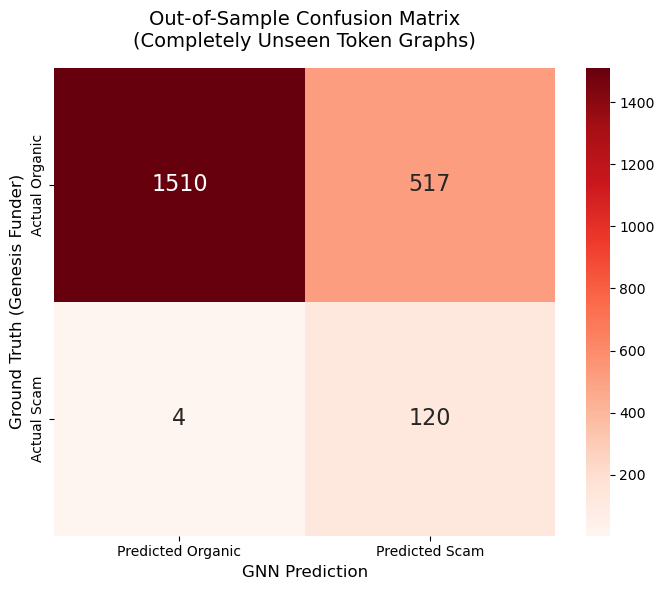


 Caught 120 out of 124 real scammers on unseen tokens (96.8% Recall)


In [43]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

test_features = []
for i, wallet in enumerate(test_wallets):
    test_features.append([
        pr_test.get(wallet, 0),               # PageRank
        ind_test.get(wallet, 0),              # In_Degree
        outd_test.get(wallet, 0),             # Out_Degree
        send_ratio_test.get(wallet, 0),       # Wallet_send_ratio (was Clustering)
        local_density_test[i],                # local_dens
        avg_neighbor_dist_test[i],            # avg_neigb_dist
        wallet_blocktime.get(wallet, 1704067200),
        wallet_funding.get(wallet, 0.5),
    ])

X_test_scaled = scaler.transform(np.array(test_features))
x_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float)

# inference on test
model.eval()
with torch.no_grad():
    logits = model(x_test_tensor, edge_index_test)
    gnn_preds = (torch.softmax(logits, dim=1)[:, 1] > 0.65).numpy().astype(int)  

cm = confusion_matrix(test_labels, gnn_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Reds',
            xticklabels=["Predicted Organic", "Predicted Scam"],
            yticklabels=["Actual Organic", "Actual Scam"],
            annot_kws={"size": 16})
plt.title("Out-of-Sample Confusion Matrix\n(Completely Unseen Token Graphs)", fontsize=14, pad=15)
plt.ylabel('Ground Truth (Genesis Funder)', fontsize=12)
plt.xlabel('GNN Prediction', fontsize=12)
plt.tight_layout()
plt.show()

caught  = ((gnn_preds == 1) & (np.array(test_labels) == 1)).sum()
total   = sum(test_labels)
print(f"\n Caught {caught} out of {total} real scammers on unseen tokens ({caught/max(total,1)*100:.1f}% Recall)")


Scam probability distribution:
  Min:    0.0000
  Max:    1.0000
  Mean:   0.2604
  > 0.5:  525 wallets flagged
  > 0.9:  312 wallets flagged
  > 0.99: 37 wallets flagged


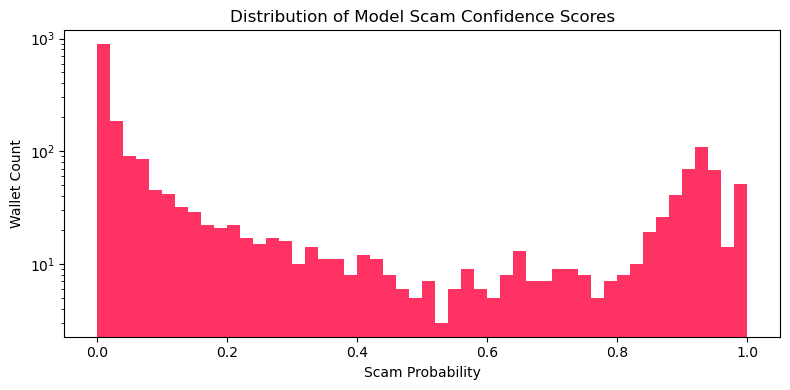

In [115]:
#selection of softmax cap hapened based on this 

probs = torch.softmax(logits, dim=1)[:, 1].numpy()
print("Scam probability distribution:")
print(f"  Min:    {probs.min():.4f}")
print(f"  Max:    {probs.max():.4f}")
print(f"  Mean:   {probs.mean():.4f}")
print(f"  > 0.5:  {(probs > 0.5).sum()} wallets flagged")
print(f"  > 0.9:  {(probs > 0.9).sum()} wallets flagged")
print(f"  > 0.99: {(probs > 0.99).sum()} wallets flagged")

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.hist(probs, bins=50, color='#ff003c', alpha=0.8)
plt.xlabel('Scam Probability')
plt.ylabel('Wallet Count')
plt.title('Distribution of Model Scam Confidence Scores')
plt.yscale('log')
plt.tight_layout()
plt.show()


In [44]:
model.eval()
with torch.no_grad():
    out   = model(data.x, data.edge_index)
    probs = torch.softmax(out, dim=1)[:, 1]  # scam probability

print("Model Output Check")
print(f"Scam prob for SCAM nodes:    {probs[data.y == 1].mean():.4f}")
print(f"Scam prob for ORGANIC nodes: {probs[data.y == 0].mean():.4f}")
print(f"Global max scam prob:        {probs.max():.4f}")
print(f"Global min scam prob:        {probs.min():.4f}")

# Check gradients actually flowed
for name, p in model.named_parameters():
    print(f"{name}: grad={p.grad.norm():.6f}, weight_norm={p.norm():.4f}")


Model Output Check
Scam prob for SCAM nodes:    0.9659
Scam prob for ORGANIC nodes: 0.1749
Global max scam prob:        0.9981
Global min scam prob:        0.0000
conv1.lin_l.weight: grad=0.026859, weight_norm=4.0844
conv1.lin_l.bias: grad=0.020415, weight_norm=1.3366
conv1.lin_r.weight: grad=0.033091, weight_norm=4.4348
conv2.lin_l.weight: grad=0.041981, weight_norm=1.6016
conv2.lin_l.bias: grad=0.004968, weight_norm=0.0918
conv2.lin_r.weight: grad=0.026473, weight_norm=2.6780


In [118]:
print(f"NaN in X:     {data.x.isnan().any()}")
print(f"Inf in X:     {data.x.isinf().any()}")
print(f"X std:        {data.x.std(dim=0)}")  # any zeros = dead feature


NaN in X:     False
Inf in X:     False
X std:        tensor([0.0207, 0.0191, 0.0116, 0.4026, 0.0456, 0.0511, 0.2855, 0.3280])


In [45]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
# XGBoost Baseline 

X_all    = data.x.numpy()
y_all    = data.y.numpy()
X_tr     = X_all[indices[:train_split].numpy()]
y_tr     = y_all[indices[:train_split].numpy()]

clf = XGBClassifier(scale_pos_weight=4.8, n_estimators=300, random_state=67)
clf.fit(X_tr, y_tr)

# ── XGBoost inference on SAME unseen test as GNN ──────────
xgb_preds = clf.predict(X_test_scaled)   # same test set as GNN 

print("XGBoost eval on held-out tokens (same test as GNN)")
print("=" * 55)
print(classification_report(
    test_labels, xgb_preds,
    target_names=["Organic (0)", "Sybil Scam (1)"],
    zero_division=0
))


XGBoost eval on held-out tokens (same test as GNN)
                precision    recall  f1-score   support

   Organic (0)       0.97      0.98      0.97      2027
Sybil Scam (1)       0.60      0.44      0.50       124

      accuracy                           0.95      2151
     macro avg       0.78      0.71      0.74      2151
  weighted avg       0.94      0.95      0.95      2151



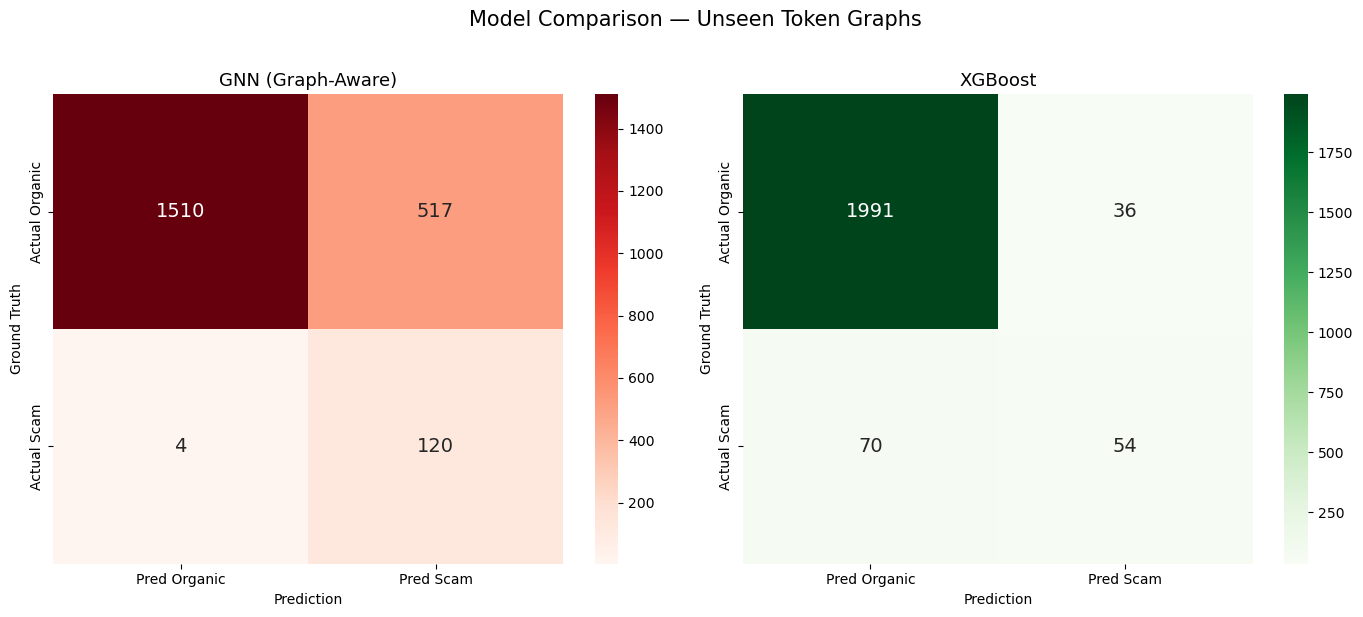


 HEAD-TO-HEAD: Sybil Scam Detection (unseen tokens)
Metric                   GNN      XGBoost     Winner
----------------------------------------------------
Accuracy               0.758        0.951    XGBoost
Recall                 0.968        0.435        GNN
Precision              0.188        0.600    XGBoost
F1                     0.315        0.505    XGBoost


In [54]:
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score 

metrics = {}
for name, p in [('GNN', gnn_preds), ('XGBoost', xgb_preds)]:
    metrics[name] = {
        'Accuracy'  : accuracy_score(test_labels, p),
        'Recall'    : recall_score(test_labels, p, pos_label=1, zero_division=0),
        'Precision' : precision_score(test_labels, p, pos_label=1, zero_division=0),
        'F1'        : f1_score(test_labels, p, pos_label=1, zero_division=0),
    }

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
cmaps     = ['Reds', 'Greens']
all_preds = [gnn_preds, xgb_preds]
titles    = ['GNN (Graph-Aware)', 'XGBoost']

for ax, p, title, cmap in zip(axes, all_preds, titles, cmaps):
    cm = confusion_matrix(test_labels, p)
    sns.heatmap(cm, annot=True, fmt='g', cmap=cmap, ax=ax,
                xticklabels=["Pred Organic", "Pred Scam"],
                yticklabels=["Actual Organic", "Actual Scam"],
                annot_kws={"size": 14})
    ax.set_title(title, fontsize=13)
    ax.set_ylabel('Ground Truth', fontsize=10)
    ax.set_xlabel('Prediction', fontsize=10)

plt.suptitle("Model Comparison — Unseen Token Graphs", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print("\n HEAD-TO-HEAD: Sybil Scam Detection (unseen tokens)")
print(f"{'Metric':<15} {'GNN':>12} {'XGBoost':>12} {'Winner':>10}")
print("-" * 52)

for metric in ['Accuracy','Recall', 'Precision', 'F1']:
    vals   = {m: metrics[m][metric] for m in metrics}
    winner = max(vals, key=vals.get)
    print(f"{metric:<15} {vals['GNN']:>12.3f} {vals['XGBoost']:>12.3f} {winner:>10}")


In [55]:
caught_gnn = ((gnn_preds == 1)      & (np.array(test_labels) == 1)).sum()
caught_xgb = ((xgb_preds == 1)  & (np.array(test_labels) == 1)).sum()
total = sum(test_labels)

print(f"\n Scammers caught out of {total}:")
print(f"   GNN:         {caught_gnn} ({caught_gnn/total*100:.1f}%)")
print(f"   XGBoost:     {caught_xgb} ({caught_xgb/total*100:.1f}%)")



 Scammers caught out of 124:
   GNN:         120 (96.8%)
   XGBoost:     54 (43.5%)


In [48]:
import plotly.express as px
import pandas as pd
import numpy as np

# Build test_df from umap_test (already computed via reducer.transform)
test_df = pd.DataFrame(umap_test, columns=['UMAP_X', 'UMAP_Y', 'UMAP_Z'])
test_df['Wallet']      = test_wallets
test_df['GNN_Pred']    = gnn_preds
test_df['True_Label']  = test_labels

# 4-way verdict: TP, FP, TN, FN
def verdict(row):
    if row['True_Label'] == 1 and row['GNN_Pred'] == 1: return 'True Scam (Caught)'
    if row['True_Label'] == 0 and row['GNN_Pred'] == 1: return 'False Alarm'
    if row['True_Label'] == 1 and row['GNN_Pred'] == 0: return 'Missed Scammer'
    return 'Organic (Clean)'

test_df['Verdict'] = test_df.apply(verdict, axis=1)

color_map = {
    'True Scam (Caught)' : '#ff003c',
    'False Alarm'        : '#ff9900',
    'Missed Scammer'     : '#9b00ff',
    'Organic (Clean)'    : '#00e5ff',
}

fig = px.scatter_3d(
    test_df,
    x='UMAP_X', y='UMAP_Y', z='UMAP_Z',
    color='Verdict',
    color_discrete_map=color_map,
    hover_name='Wallet',
    title="3D Scammer Topography — GNN on Unseen Token Graphs"
)

fig.update_traces(marker=dict(size=4, opacity=0.75), selector=dict(mode='markers'))
fig.update_layout(
    template="plotly_dark",
    margin=dict(l=0, r=0, b=0, t=50),
    legend_title_text='GNN Verdict'
)
fig.show()


In [49]:
# ── Export Main Notebook Results ───────────────────────────────────────────────
import pandas as pd
import json
from sklearn.metrics import classification_report

RESULTS_DIR = "../exported_data/"   # same folder as graphs.ipynb

# ── 1. Summary CSV ─────────────────────────────────────────────────────────────
main_rows = []
for name, preds in [("GNN (GraphSAGE-main)", gnn_preds), ("XGBoost", xgb_preds)]:
    main_rows.append({
        "Model"          : name,
        "Notebook"       : "feature_engineering.ipynb",
        "Recall_Scam"    : recall_score(test_labels, preds, pos_label=1, zero_division=0),
        "Precision_Scam" : precision_score(test_labels, preds, pos_label=1, zero_division=0),
        "F1_Scam"        : f1_score(test_labels, preds, pos_label=1, zero_division=0),
        "Caught"         : int(((np.array(preds)==1)&(np.array(test_labels)==1)).sum()),
        "Total_Scam"     : int(sum(test_labels)),
        "Threshold"      : 0.7,
    })

main_summary_df = pd.DataFrame(main_rows)

# Append to existing model_comparison.csv (or create if not there yet)
try:
    existing = pd.read_csv(RESULTS_DIR + "model_comparison.csv")
    # Remove stale entries from this notebook to avoid duplicates on re-run
    existing = existing[existing["Notebook"] != "feature_engineering.ipynb"]
    combined = pd.concat([existing, main_summary_df], ignore_index=True)
except FileNotFoundError:
    combined = main_summary_df

combined.to_csv(RESULTS_DIR + "model_comparison.csv", index=False)
print("✓ Saved/updated: model_comparison.csv")

# ── 2. Full Classification Reports (JSON) ──────────────────────────────────────
main_reports = {}
for name, preds in [("GNN (GraphSAGE-main)", gnn_preds), ("XGBoost", xgb_preds)]:
    main_reports[name] = classification_report(
        test_labels, preds,
        target_names=["Organic", "Scam"],
        output_dict=True
    )

with open(RESULTS_DIR + "classification_reports_main.json", "w") as f:
    json.dump(main_reports, f, indent=2)
print("✓ Saved: classification_reports_main.json")

# ── 3. Master View ─────────────────────────────────────────────────────────────
print("\n── All Models Across Both Notebooks ──")
cols = ["Notebook", "Recall_Scam", "Precision_Scam", "F1_Scam", "Caught", "Total_Scam"]
print(combined.set_index("Model")[cols].round(3).to_string())


✓ Saved/updated: model_comparison.csv
✓ Saved: classification_reports_main.json

── All Models Across Both Notebooks ──
                                       Notebook  Recall_Scam  Precision_Scam  F1_Scam  Caught  Total_Scam
Model                                                                                                    
GCN                                graphs.ipynb        0.992           0.256    0.407     123         124
GAT                                graphs.ipynb        0.992           0.254    0.404     123         124
GNN (GraphSAGE-main)  feature_engineering.ipynb        0.968           0.188    0.315     120         124
XGBoost               feature_engineering.ipynb        0.435           0.600    0.505      54         124


As we can see, the model is very good at actually finding scam wallets when they are actually labeled as scam (Recall hit 0.92) 
However, it missclassifies and predicts a lot of actually non scam wallets as scams.
Now this is ok, in the sense that since its crypto and TRENCHES crypto (DEX level scam paradise) , its better to be safe than sorry 
HOWEVER , what if the labeling is wrong? What if actually way more wallets are actually scams but we failed to label them correctly? 


**WE WILL EXPERIMENT, TAKING ACTION ON THE LABELS BEFORE EVEN TRAINING**



For this , we will use Jaccard Similarity , and more importantly something called Jaccard INFECTION. 
How does it work? 
Lets go back to our edges, if Wallet A and wallet B share x% of their traiding partners ( Jaccard > x), we forcefully change wallet B label to scammer 
